In [40]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [41]:
conversation_results_multiple_runs_per_model = pl.read_csv(
    "healthbench_granular_data_20251209.tsv", separator="\t"
)
conversation_results_multiple_runs_per_model.head()

model,run_id,conversation_id,rubric_criterion_index,axis,points,criterion_met,theme
str,str,str,i64,str,i64,bool,str
"""llama-4-maverick-temp0""","""20251209_122215""","""8f2a65de-dea7-48e8-8adb-6194ec…",0,"""context_awareness""",8,false,"""global_health"""
"""llama-4-maverick-temp0""","""20251209_122215""","""8f2a65de-dea7-48e8-8adb-6194ec…",1,"""completeness""",9,true,"""global_health"""
"""llama-4-maverick-temp0""","""20251209_122215""","""8f2a65de-dea7-48e8-8adb-6194ec…",2,"""completeness""",9,false,"""global_health"""
"""llama-4-maverick-temp0""","""20251209_122215""","""8f2a65de-dea7-48e8-8adb-6194ec…",3,"""completeness""",-8,true,"""global_health"""
"""llama-4-maverick-temp0""","""20251209_122215""","""8f2a65de-dea7-48e8-8adb-6194ec…",4,"""completeness""",8,true,"""global_health"""


In [20]:
# Old approach

# Let's keep just one run from the models that ran multiple times. We will do
# that by dropping all rows for a given model that don't have a particular
# run_id. If a model doesn't show up in this list it's because it only had one
# run to begin with

# runs_to_keep = [
#     ("llama-3.3-70b", "20251029_012947"),
#     ("llama-4-maverick", "20251027_165626"),
#     ("llama-4-scout", "20251027_091851"),
# ]
# conversation_results = conversation_results_multiple_runs_per_model
# for model_name, run_id in runs_to_keep:
#     conversation_results = conversation_results.filter(
#         (pl.col("model") != model_name)
#         | ((pl.col("model") == model_name) & (pl.col("run_id") == run_id))
#     )

In [42]:
# Jason's approach


def filter_to_first_run(group: pl.DataFrame) -> pl.DataFrame:
    first_run = group["run_id"].min()
    assert first_run is not None
    return group.filter(pl.col("run_id") == first_run)


conversation_results = conversation_results_multiple_runs_per_model.group_by(
    "model"
).map_groups(filter_to_first_run)

# Check that the filtering worked correctly - we should see one run per model
unique_model_runs = (
    conversation_results.select("model", "run_id").unique().sort("model")
)
assert len(unique_model_runs) == len(
    conversation_results_multiple_runs_per_model.select("model").unique()
)

In [43]:
def get_mean_and_confidence_intervals(scores: pl.Series) -> dict:
    scores_np = scores.to_numpy()
    mean = np.clip(np.mean(scores_np), 0, 1).item()
    lower, upper = np.percentile(
        [np.mean(np.random.choice(scores_np, len(scores_np))) for _ in range(1000)],
        [2.5, 97.5],
    )
    return {"mean": mean, "lower_ci": float(lower), "upper_ci": float(upper)}

In [44]:
theme_results = (
    conversation_results.vstack(
        # Add another copy of the DF where all conversations are duplicated
        # under the "all" theme, in order to calculate the overall score and CIs
        conversation_results.with_columns(pl.lit("all").alias("theme"))
    )
    .with_columns(
        # Determine whether the points should actually be awarded for each criterion
        pl.when("criterion_met")
        .then("points")
        .otherwise(pl.lit(0))
        .alias("criterion_points_awarded"),
    )
    .group_by("model", "run_id", "theme", "conversation_id")
    .agg(
        # Calculate the total number of points possible for the conversation
        pl.col("points")
        .filter(pl.col("points") > 0)
        .sum()
        .alias("conversation_points_possible"),
        # Sum the points awarded for this conversation, note that the score for an
        # individual conversation can be negative, but the overall/theme/axis score
        # is clipped to a minimum of 0
        pl.col("criterion_points_awarded").sum().alias("conversation_points_awarded"),
    )
    .with_columns(
        # Calculate the score for each conversation
        (
            pl.col("conversation_points_awarded")
            / pl.col("conversation_points_possible")
        ).alias("conversation_score")
    )
    .group_by("model", "run_id", "theme")
    .agg(
        # Calculate a mean with CI at the run level
        pl.col("conversation_score")
        .map_batches(function=get_mean_and_confidence_intervals, returns_scalar=True)
        .alias("results_struct"),
        pl.col("model").count().alias("n"),
    )
    .unnest("results_struct")
)

In [45]:
theme_results.select("theme").unique()

theme
str
"""communication"""
"""context_seeking"""
"""all"""
"""emergency_referrals"""
"""global_health"""
"""hedging"""
"""health_data_tasks"""


In [46]:
axis_results = (
    conversation_results.vstack(
        # Add another copy of the DF where all conversations a duplicated under the
        # "all" theme, in order to calculate the overall score and CI
        conversation_results.with_columns(pl.lit("all").alias("axis"))
    )
    .with_columns(
        # Determine whether the points should actually be awarded for each criterion
        pl.when("criterion_met")
        .then("points")
        .otherwise(pl.lit(0))
        .alias("criterion_points_awarded"),
    )
    .group_by("model", "run_id", "axis", "conversation_id")
    .agg(
        # Calculate the total number of points possible for the conversation
        pl.col("points")
        .filter(pl.col("points") > 0)
        .sum()
        .alias("conversation_points_possible"),
        # Sum the points awarded for this quesiton, note that the score for an
        # individual question can be negative, but the overall/theme/axis score
        # is clipped to a minimum of 0
        pl.col("criterion_points_awarded").sum().alias("conversation_points_awarded"),
    )
    # Filter out questions that do not have any criteria for a given axis
    .filter(pl.col("conversation_points_possible") > 0)
    .with_columns(
        # Calculate the score for each conversation
        (
            pl.col("conversation_points_awarded")
            / pl.col("conversation_points_possible")
        ).alias("conversation_score")
    )
    .group_by("model", "run_id", "axis")
    .agg(
        # Calculate a mean with CI at the run level
        pl.col("conversation_score")
        .map_batches(function=get_mean_and_confidence_intervals, returns_scalar=True)
        .alias("results_struct")
    )
    .unnest("results_struct")
)

In [47]:
axis_results.select("axis").unique()

axis
str
"""accuracy"""
"""instruction_following"""
"""communication_quality"""
"""all"""
"""completeness"""
"""context_awareness"""


In [48]:
sns.set_style("whitegrid")

(0.0, 0.65)

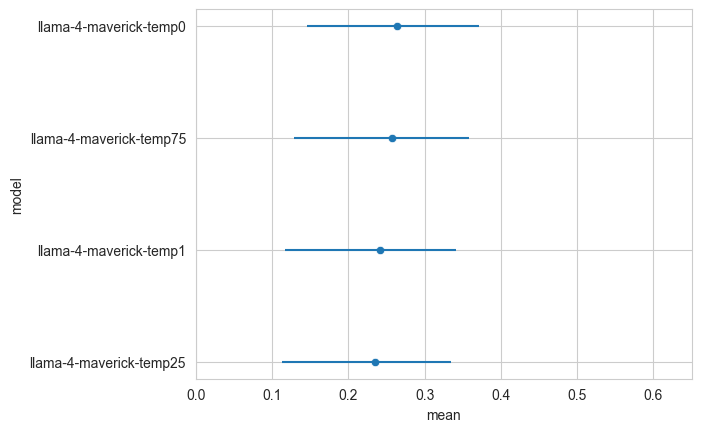

In [49]:
# Plot overall results
overall_results = theme_results.filter(pl.col("theme") == "all").sort(
    "mean", descending=True
)
g = sns.scatterplot(data=overall_results, x="mean", y="model")
plt.hlines(
    overall_results["model"], overall_results["lower_ci"], overall_results["upper_ci"]
)
g.set_xlim(0, 0.65)

In [39]:
overall_results

model,run_id,theme,mean,lower_ci,upper_ci,n
str,str,str,f64,f64,f64,u32
"""o3""","""20251029_151631""","""all""",0.595808,0.585544,0.604852,5000
"""llama-4-maverick-enhanced-prom…","""20251208_122142""","""all""",0.302824,0.292248,0.312321,5000
"""llama-4-maverick-enhanced-prom…","""20251128_141534""","""all""",0.29946,0.288675,0.31037,5000
"""llama-3.3-70b-enhanced-prompt-…","""20251130_205416""","""all""",0.292482,0.280781,0.302827,5000
"""llama-4-scout-enhanced-prompt-…","""20251130_205416""","""all""",0.277122,0.266343,0.287213,5000
…,…,…,…,…,…,…
"""llama-4-maverick-rag""","""20251118_161039""","""all""",0.223284,0.21226,0.23414,5000
"""llama-4-scout-rag""","""20251118_204328""","""all""",0.223146,0.212769,0.233475,5000
"""llama-4-maverick-rag2""","""20251120_175439""","""all""",0.221938,0.211238,0.232855,5000


(0.0, 0.65)

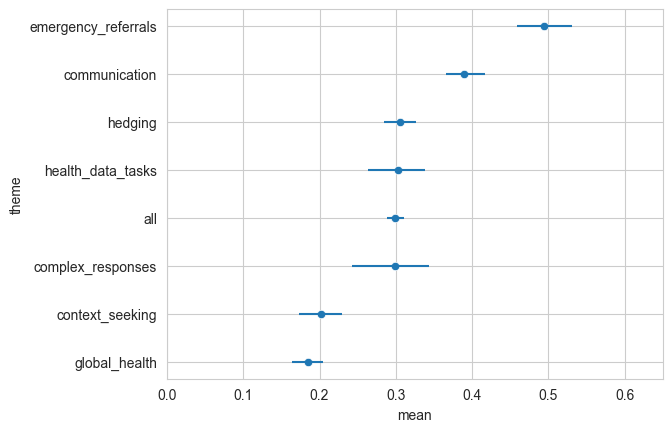

In [13]:
# Plot theme results
plot_df = theme_results.filter(
    pl.col("model") == "llama-4-maverick-enhanced-prompt-completeness-3"
).sort("mean", descending=True)
g = sns.scatterplot(data=plot_df, x="mean", y="theme")
plt.hlines(plot_df["theme"], plot_df["lower_ci"], plot_df["upper_ci"])
g.set_xlim(0, 0.65)

## Plot Results Relative to a Baseline

In [13]:
unique_model_runs

model,run_id
str,str
"""llama-3.1-8b""","""20251030_123814"""
"""llama-3.3-70b""","""20251028_162900"""
"""llama-4-maverick""","""20251023_212754"""
"""llama-4-maverick-enhanced-prom…","""20251119_223124"""
"""llama-4-maverick-rag""","""20251118_161039"""
…,…
"""llama-4-scout""","""20251023_153707"""
"""llama-4-scout-enhanced-prompt""","""20251119_213733"""
"""llama-4-scout-rag""","""20251118_204328"""


In [14]:
model_baseline_map = {
    "llama-3.1-8b": [],
    "llama-3.3-70b": [],
    "llama-4-maverick": [
        "llama-4-maverick-rag",
        "llama-4-maverick-rag2",
        "llama-4-maverick-enhanced-prompt",
        "llama-4-maverick-enhanced-prompt-completeness-3",
    ],
    "llama-4-scout": [
        "llama-4-scout-rag",
        "llama-4-scout-rag2",
        "llama-4-scout-enhanced-prompt",
    ],
    "o3": [],
}

In [15]:
# Calculate theme performance for maverick relative to the baseline
baseline_model = "llama-4-maverick"


def subtract_baseline_mean(s: pl.DataFrame) -> pl.DataFrame:
    """
    Subtracts the baseline mean from the non-baseline means, and confidence
    limits.
    """
    baseline = s.filter(pl.col("model") == baseline_model)
    rest = s.filter(pl.col("model") != baseline_model)
    return rest.with_columns(
        (pl.col("mean") - baseline["mean"].item()).alias("relative_mean"),
        (pl.col("lower_ci") - baseline["mean"].item()).alias("relative_lower_ci"),
        (pl.col("upper_ci") - baseline["mean"].item()).alias("relative_upper_ci"),
    )


iteration_models = model_baseline_map[baseline_model]
relative_theme_performance = (
    theme_results.filter(
        # Filter the dataframe down to only the baseline model and its later
        # iterations
        (pl.col("model") == baseline_model) | pl.col("model").is_in(iteration_models)
    )
    .group_by("theme")
    .map_groups(subtract_baseline_mean)
    .sort("theme", "model")
)
relative_axis_performance = (
    axis_results.filter(
        (pl.col("model") == baseline_model) | pl.col("model").is_in(iteration_models)
    )
    .group_by("axis")
    .map_groups(subtract_baseline_mean)
    .sort("axis", "model")
)

relative_axis_performance

model,run_id,axis,mean,lower_ci,upper_ci,relative_mean,relative_lower_ci,relative_upper_ci
str,str,str,f64,f64,f64,f64,f64,f64
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""accuracy""",0.406297,0.391194,0.420719,-0.010564,-0.025667,0.003858
"""llama-4-maverick-enhanced-prom…","""20251128_141534""","""accuracy""",0.434455,0.419168,0.449515,0.017594,0.002307,0.032654
"""llama-4-maverick-rag""","""20251118_161039""","""accuracy""",0.400023,0.385304,0.414392,-0.016838,-0.031557,-0.002469
"""llama-4-maverick-rag2""","""20251120_175439""","""accuracy""",0.408853,0.393105,0.423535,-0.008008,-0.023756,0.006674
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""all""",0.252568,0.241609,0.263015,-0.011877,-0.022837,-0.001431
…,…,…,…,…,…,…,…,…
"""llama-4-maverick-rag2""","""20251120_175439""","""context_awareness""",0.246974,0.225007,0.269987,-0.020427,-0.042394,0.002587
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""instruction_following""",0.490718,0.457323,0.521677,0.003952,-0.029443,0.034911
"""llama-4-maverick-enhanced-prom…","""20251128_141534""","""instruction_following""",0.497801,0.464781,0.530091,0.011036,-0.021984,0.043325


Text(0.5, 1.0, 'Themes - llama-4-maverick-enhanced-prompt-completeness-3')

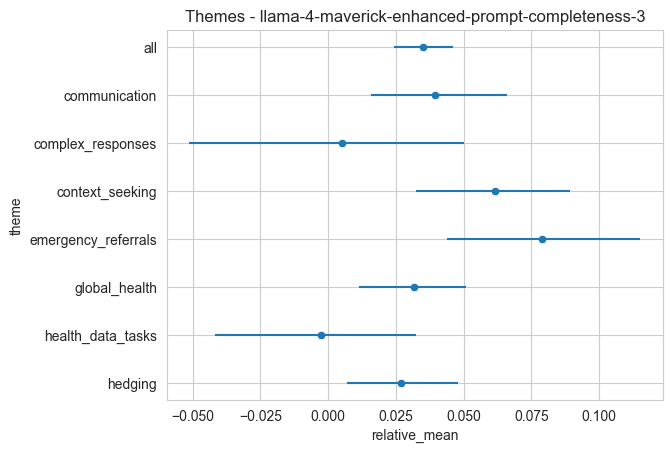

In [16]:
# Plot theme results relative to the baseline mean
target_model = "llama-4-maverick-enhanced-prompt-completeness-3"
plot_df = relative_theme_performance.filter(pl.col("model") == target_model)
g = sns.scatterplot(
    data=plot_df,
    x="relative_mean",
    y="theme",
)
plt.hlines(
    plot_df["theme"],
    plot_df["relative_lower_ci"],
    plot_df["relative_upper_ci"],
)
g.set_title(f"Themes - {target_model}")

Text(0.5, 1.0, 'Axes - llama-4-maverick-enhanced-prompt-completeness-3')

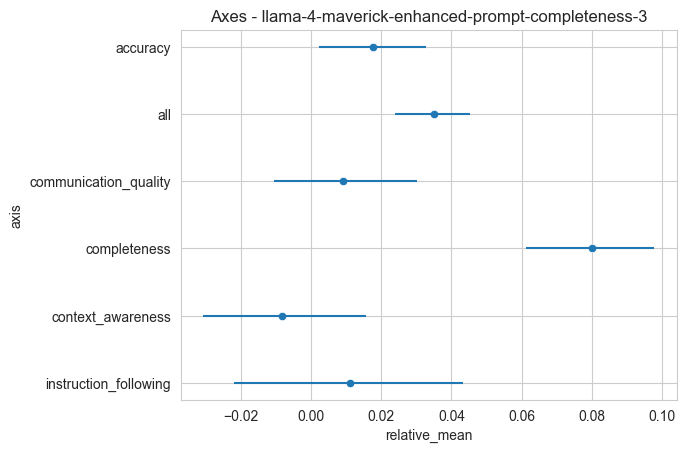

In [17]:
# Plot axis results relative to the baseline mean
taget_model = "llama-4-maverick-enhanced-prompt-completeness-3"

plot_df = relative_axis_performance.filter(pl.col("model") == target_model)
g = sns.scatterplot(data=plot_df, x="relative_mean", y="axis")
plt.hlines(
    plot_df["axis"],
    plot_df["relative_lower_ci"],
    plot_df["relative_upper_ci"],
)
g.set_title(f"Axes - {target_model}")